# LLM Evaluation Comparison — 6.042J (Math for CS)

Compares three LLM judges (**GPT-5.4**, **Claude 4.6 Opus**, **Gemini 3.1 Pro**) across all evaluation dimensions, and contrasts LLM scores against the metric-computed baseline from `6.042J_results.jsonl`.

**Aspects & Dimensions**
- **Pedagogical**: curriculum_alignment, cognitive_demand, concept_coverage, response_burden
- **Psychometric**: difficulty, discrimination, guessing_careless*, distractor_functioning, item_fit, dimensionality, reliability
- **Linguistic & Structural**: readability, linguistic_complexity, ambiguity, well_formedness, diversity
- **Fairness & Ethics**: group_bias, measurement_invariance, content_sensitivity, harmful_content_risk, privacy_risk

\* `guessing_careless` not scored by LLMs — excluded from LLM aggregates (NaN).

In [1]:
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RESULTS_DIR = pathlib.Path('../data/results')
LLM_DIR = RESULTS_DIR / 'llm_eval'

ASPECTS = {
    'pedagogical':           ['curriculum_alignment', 'cognitive_demand', 'concept_coverage', 'response_burden'],
    'psychometric':          ['difficulty', 'discrimination', 'guessing_careless', 'distractor_functioning', 'item_fit', 'dimensionality', 'reliability'],
    'linguistic_structural': ['readability', 'linguistic_complexity', 'ambiguity', 'well_formedness', 'diversity'],
    'fairness_ethics':       ['group_bias', 'measurement_invariance', 'content_sensitivity', 'harmful_content_risk', 'privacy_risk'],
}
ALL_DIMS = [dim for dims in ASPECTS.values() for dim in dims]
dim_to_aspect = {dim: asp for asp, dims in ASPECTS.items() for dim in dims}

LLM_FILES = {
    'GPT-5.4':         LLM_DIR / '6.042J_gpt5.4_results.jsonl',
    'Claude 4.6 Opus': LLM_DIR / '6.042J_claude4.6opus_results.jsonl',
    'Gemini 3.1 Pro':  LLM_DIR / '6.042J_gemini3.1pro_results.jsonl',
}
METRIC_FILE = RESULTS_DIR / '6.042J_results.jsonl'

COLORS = {
    'GPT-5.4':         '#4C72B0',
    'Claude 4.6 Opus': '#DD8452',
    'Gemini 3.1 Pro':  '#55A868',
    'Metrics':         '#C44E52',
}

print('File check:')
for name, p in {**LLM_FILES, 'Metrics': METRIC_FILE}.items():
    print(f'  {name}: {"OK" if p.exists() else "MISSING"}')

File check:
  GPT-5.4: OK
  Claude 4.6 Opus: OK
  Gemini 3.1 Pro: OK
  Metrics: OK


## 1 — Load Data

In [2]:
def load_llm_file(path):
    """LLM files are comma-separated JSON objects (not JSONL). Wrap in [] to parse as array."""
    with open(path) as f:
        content = f.read().strip()
    return json.loads('[' + content + ']')


def load_metric_file(path):
    """Standard JSONL: one JSON object per line."""
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def extract_llm_scores(records):
    """LLM records: scores.aspect.dimension.score (dimension-level scores)."""
    rows = []
    for r in records:
        row = {'question_id': r['question_id']}
        for aspect, dims in ASPECTS.items():
            for dim in dims:
                val = r.get('scores', {}).get(aspect, {}).get(dim, {})
                row[dim] = val.get('score', np.nan) if isinstance(val, dict) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('question_id')


def extract_metric_scores(records):
    """Metric records: scores.aspect.dimension.metric_name.score. Aggregate to dimension level."""
    rows = []
    for r in records:
        row = {'question_id': r['question_id']}
        for aspect, dims in ASPECTS.items():
            for dim in dims:
                metrics = r.get('scores', {}).get(aspect, {}).get(dim, {})
                metric_scores = [
                    v['score'] for v in metrics.values()
                    if isinstance(v, dict) and isinstance(v.get('score'), (int, float))
                ]
                row[dim] = float(np.mean(metric_scores)) if metric_scores else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('question_id')


llm_dfs   = {name: extract_llm_scores(load_llm_file(path)) for name, path in LLM_FILES.items()}
metric_df = extract_metric_scores(load_metric_file(METRIC_FILE))
all_dfs   = {**llm_dfs, 'Metrics': metric_df}

# Shared dimensions: present in at least some records for every source
shared_dims = [d for d in ALL_DIMS if all(df[d].notna().any() for df in all_dfs.values())]
excluded    = set(ALL_DIMS) - set(shared_dims)

# Common question IDs across all sources
common_ids = metric_df.index
for df in llm_dfs.values():
    common_ids = common_ids.intersection(df.index)

print('Loaded:')
for name, df in all_dfs.items():
    print(f'  {name}: {len(df)} questions, {df[shared_dims].notna().sum().sum()} scored cells')
print(f'\nCommon questions: {len(common_ids)}')
print(f'Shared dims ({len(shared_dims)}): {shared_dims}')
if excluded:
    print(f'Excluded (NaN in all LLMs): {excluded}')

Loaded:
  GPT-5.4: 126 questions, 1260 scored cells
  Claude 4.6 Opus: 126 questions, 1260 scored cells
  Gemini 3.1 Pro: 126 questions, 1260 scored cells
  Metrics: 126 questions, 1260 scored cells

Common questions: 126
Shared dims (10): ['curriculum_alignment', 'cognitive_demand', 'concept_coverage', 'response_burden', 'readability', 'linguistic_complexity', 'ambiguity', 'well_formedness', 'diversity', 'privacy_risk']
Excluded (NaN in all LLMs): {'guessing_careless', 'difficulty', 'item_fit', 'measurement_invariance', 'reliability', 'distractor_functioning', 'content_sensitivity', 'harmful_content_risk', 'discrimination', 'group_bias', 'dimensionality'}


## 2 — Mean Scores per Dimension

In [3]:
summary = pd.DataFrame({name: df[ALL_DIMS].mean() for name, df in all_dfs.items()})
summary.index.name = 'dimension'
summary.insert(0, 'aspect', summary.index.map(dim_to_aspect))
print(summary.to_string(float_format='{:.3f}'.format))

                                       aspect  GPT-5.4  Claude 4.6 Opus  Gemini 3.1 Pro  Metrics
dimension                                                                                       
curriculum_alignment              pedagogical    0.851            0.783           0.941    0.271
cognitive_demand                  pedagogical    0.573            0.675           0.844    0.504
concept_coverage                  pedagogical    0.832            0.851           0.939    0.210
response_burden                   pedagogical    0.576            0.886           0.874    0.421
difficulty                       psychometric    0.720            0.638           0.794      NaN
discrimination                   psychometric    0.643            0.752           0.845      NaN
guessing_careless                psychometric      NaN              NaN             NaN      NaN
distractor_functioning           psychometric    0.414            0.664           0.794      NaN
item_fit                      

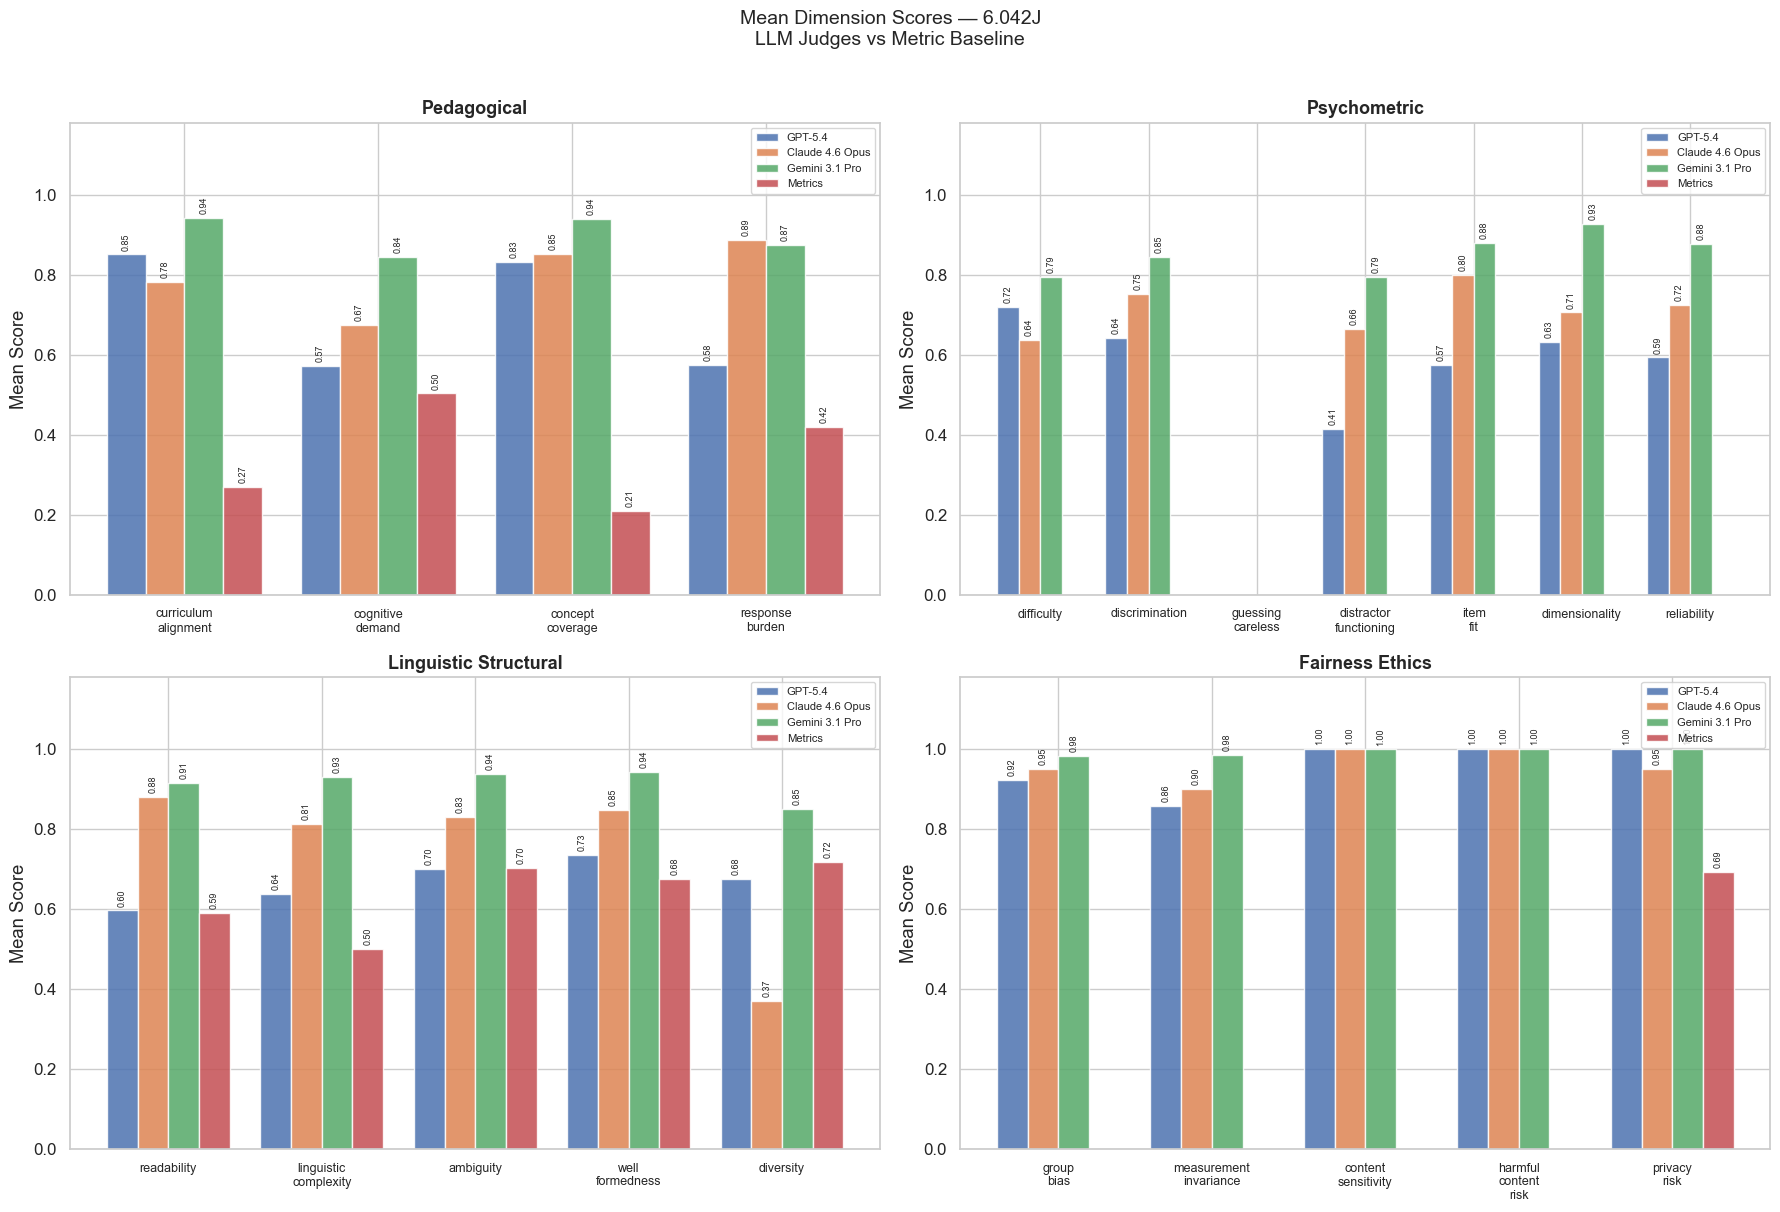

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
source_names = list(all_dfs.keys())
bar_colors   = [COLORS[n] for n in source_names]

for ax, (aspect, dims) in zip(axes, ASPECTS.items()):
    sub = summary.loc[dims].drop(columns='aspect')
    x, width = np.arange(len(dims)), 0.2
    for i, col in enumerate(sub.columns):
        vals = sub[col].values
        bars = ax.bar(x + i * width, np.nan_to_num(vals), width, label=col,
                      color=bar_colors[i], alpha=0.85)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=6.5, rotation=90)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([d.replace('_', '\n') for d in dims], fontsize=9)
    ax.set_ylim(0, 1.18)
    ax.set_title(aspect.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean Score')
    ax.legend(fontsize=8)

plt.suptitle('Mean Dimension Scores — 6.042J\nLLM Judges vs Metric Baseline', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(LLM_DIR / '6.042J_dimension_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — Inter-Source Pearson Correlation Heatmap

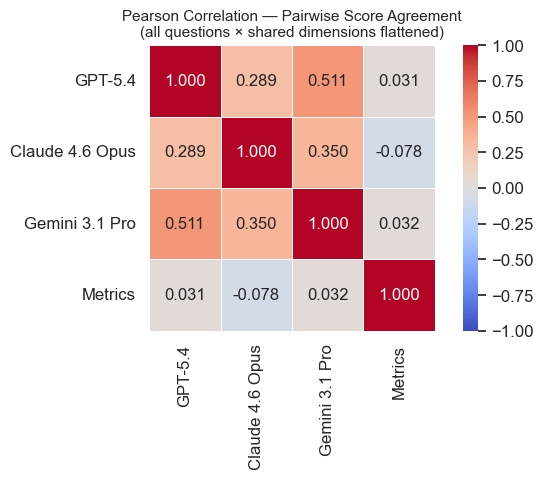

In [5]:
stacked = {}
for name, df in all_dfs.items():
    stacked[name] = df.loc[common_ids, shared_dims].values.flatten()

names = list(all_dfs.keys())
corr_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        mask = ~(np.isnan(stacked[a]) | np.isnan(stacked[b]))
        corr_matrix.loc[a, b] = stats.pearsonr(stacked[a][mask], stacked[b][mask])[0] if mask.sum() > 1 else np.nan

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, square=True, annot_kws={'size': 12})
ax.set_title('Pearson Correlation — Pairwise Score Agreement\n(all questions × shared dimensions flattened)', fontsize=11)
plt.tight_layout()
plt.savefig(LLM_DIR / '6.042J_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Score Distributions (Box Plots per Aspect)

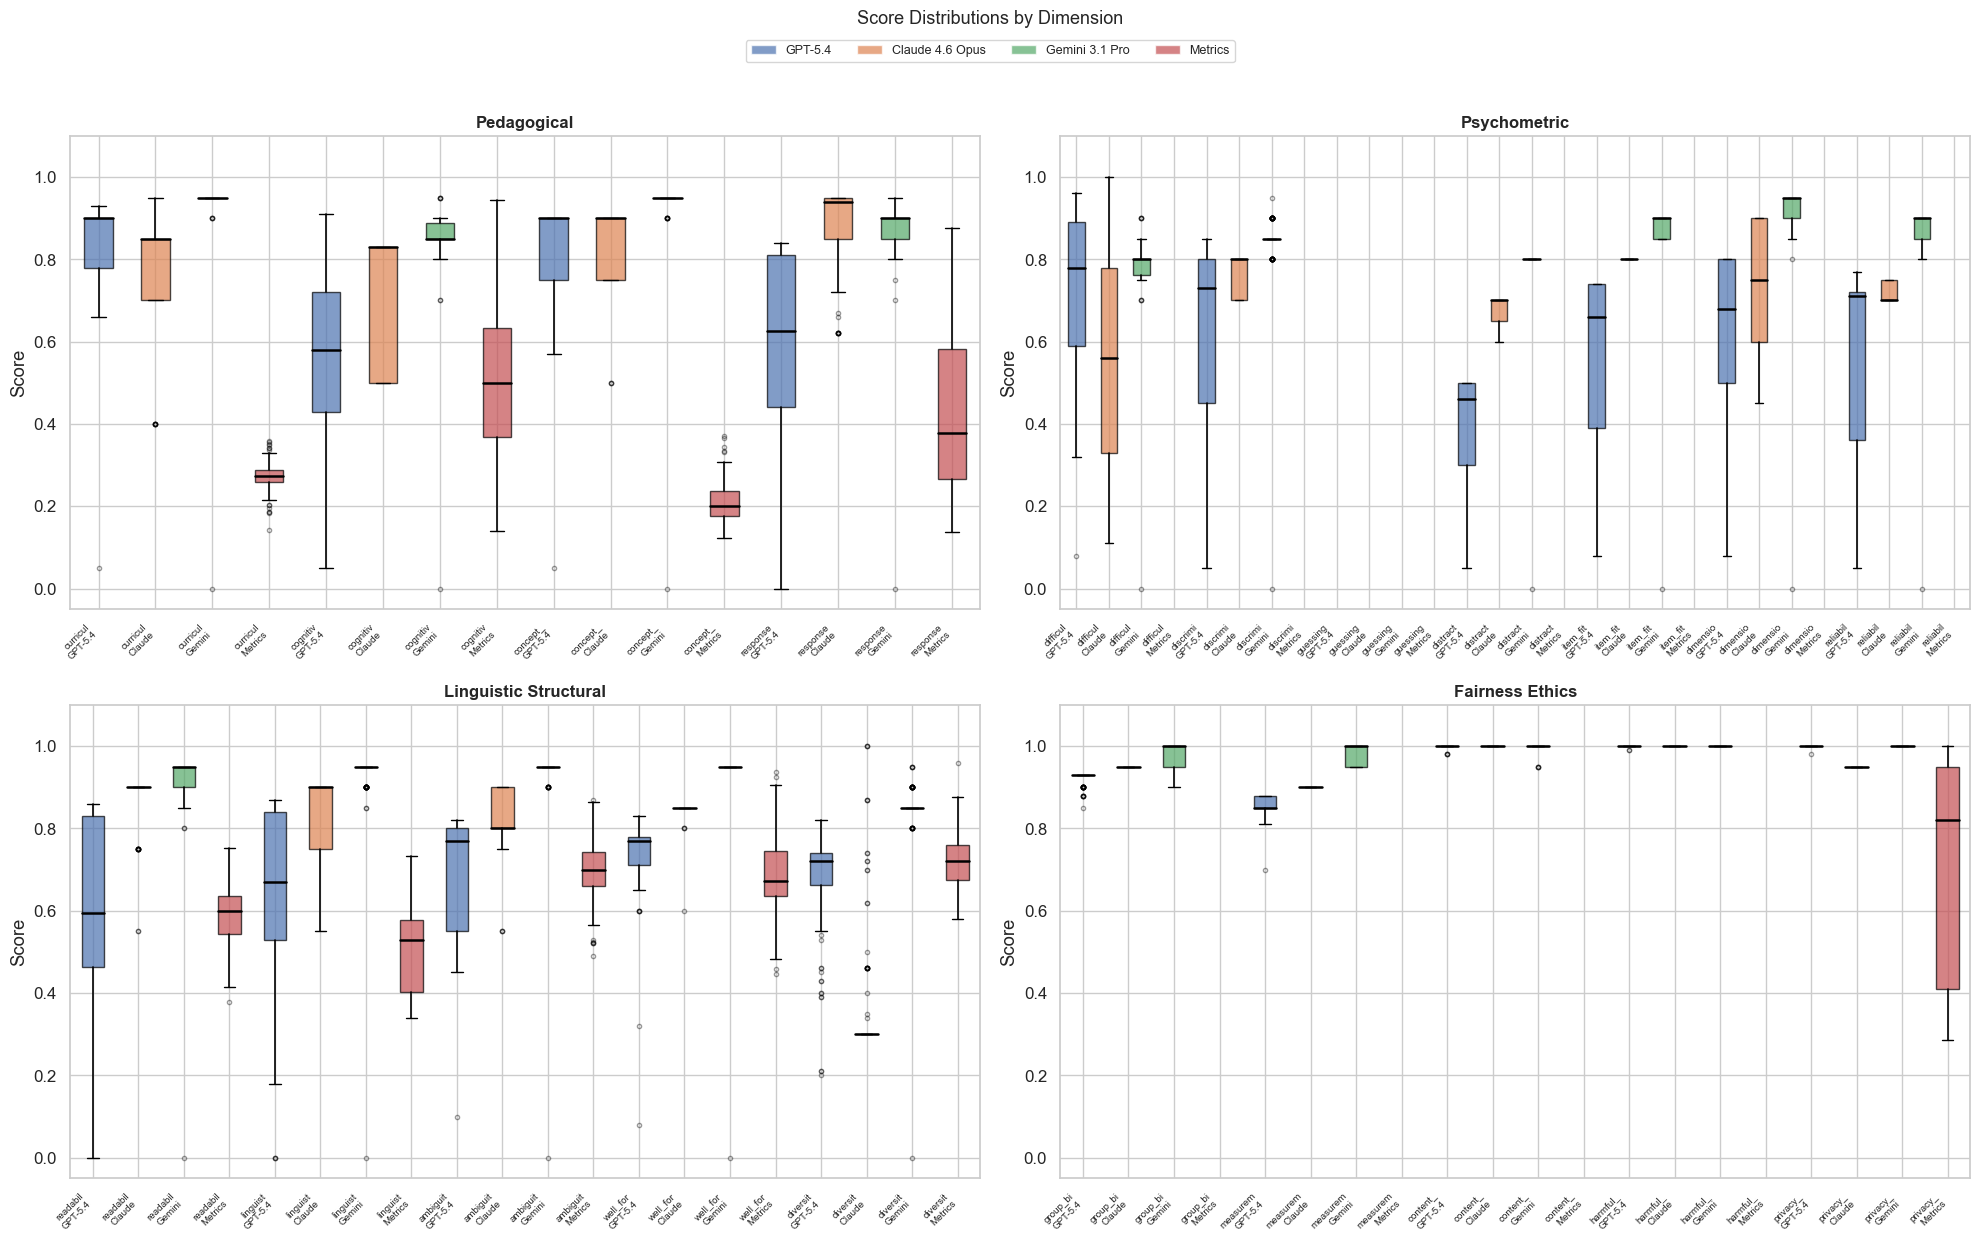

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for ax, (aspect, dims) in zip(axes, ASPECTS.items()):
    plot_data, plot_labels, plot_colors = [], [], []
    for dim in dims:
        for name, df in all_dfs.items():
            vals = df.loc[common_ids, dim].dropna().values
            plot_data.append(vals)
            plot_labels.append(f"{dim[:8]}\n{name.split()[0]}")
            plot_colors.append(COLORS[name])

    bp = ax.boxplot(plot_data, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.8),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, color in zip(bp['boxes'], plot_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(plot_data) + 1))
    ax.set_xticklabels(plot_labels, fontsize=7, rotation=45, ha='right')
    ax.set_title(aspect.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_ylim(-0.05, 1.1)
    ax.set_ylabel('Score')

legend_elements = [Patch(facecolor=COLORS[n], alpha=0.7, label=n) for n in all_dfs]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Score Distributions by Dimension', fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig(LLM_DIR / '6.042J_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — LLM vs Metric Baseline: Scatter Grid

/Users/omaramraninejjar/opt/anaconda3/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


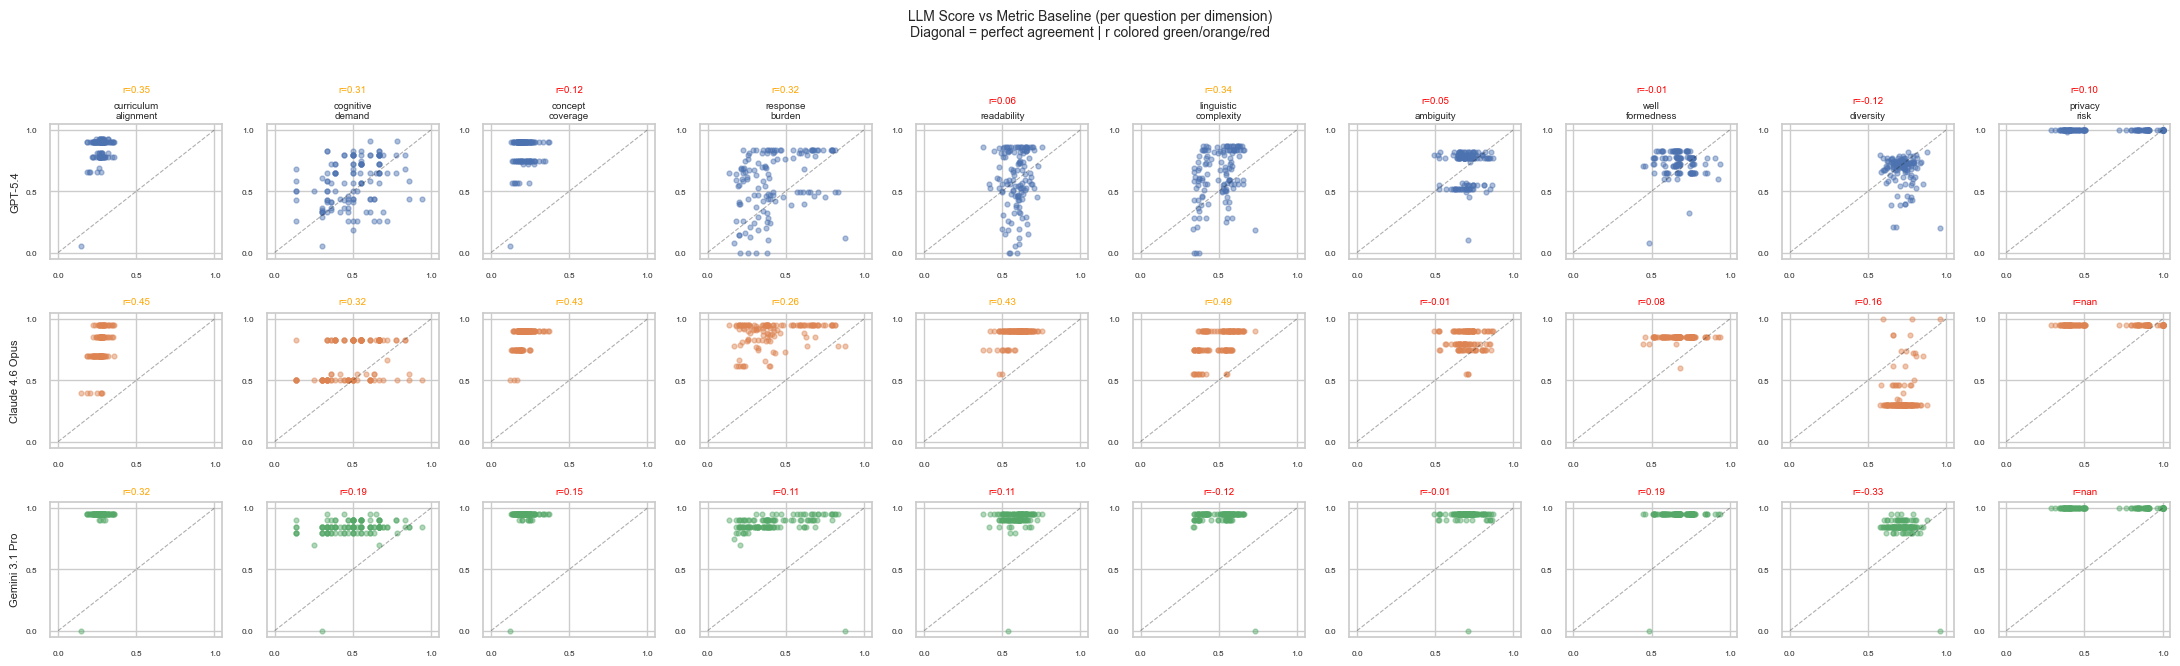

In [7]:
n_dims = len(shared_dims)
n_llms = len(llm_dfs)
fig, axes = plt.subplots(n_llms, n_dims, figsize=(n_dims * 2.2, n_llms * 2.2))

for row, (llm_name, llm_df) in enumerate(llm_dfs.items()):
    for col, dim in enumerate(shared_dims):
        ax = axes[row][col]
        x = metric_df.loc[common_ids, dim].values
        y = llm_df.loc[common_ids, dim].values
        mask = ~(np.isnan(x) | np.isnan(y))
        ax.scatter(x[mask], y[mask], alpha=0.45, s=12, color=COLORS[llm_name])
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.35)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        if mask.sum() > 1:
            r, _ = stats.pearsonr(x[mask], y[mask])
            color = 'green' if r > 0.5 else ('orange' if r > 0.2 else 'red')
            ax.set_title(f'r={r:.2f}', fontsize=7, color=color)
        if row == 0:
            ax.set_xlabel(dim.replace('_', '\n'), fontsize=7)
            ax.xaxis.set_label_position('top')
        if col == 0:
            ax.set_ylabel(llm_name, fontsize=8)
        ax.tick_params(labelsize=6)
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([0, 0.5, 1])

plt.suptitle('LLM Score vs Metric Baseline (per question per dimension)\nDiagonal = perfect agreement | r colored green/orange/red',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(LLM_DIR / '6.042J_scatter_grid.png', dpi=130, bbox_inches='tight')
plt.show()

## 6 — Aspect-Level Radar Chart

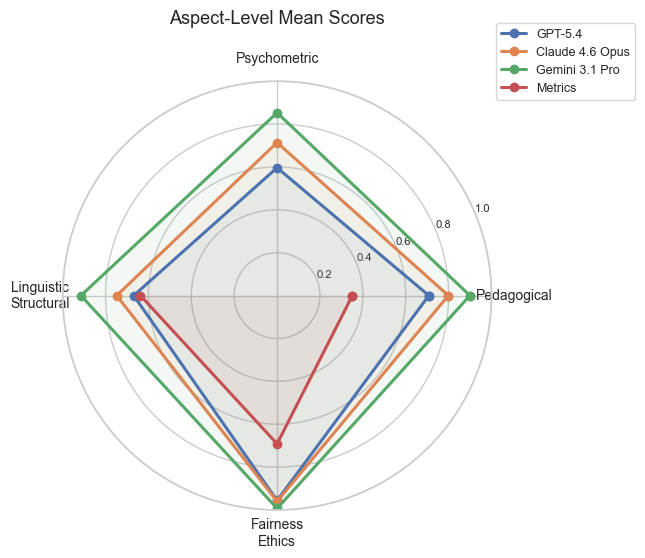

In [8]:
aspect_names = list(ASPECTS.keys())
N = len(aspect_names)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for name, df in all_dfs.items():
    vals = [df.loc[common_ids, dims].mean(skipna=True).mean() for dims in ASPECTS.values()]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2.2, label=name, color=COLORS[name])
    ax.fill(angles, vals, alpha=0.07, color=COLORS[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([a.replace('_', '\n').title() for a in aspect_names], size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8)
ax.set_title('Aspect-Level Mean Scores', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig(LLM_DIR / '6.042J_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — Flagging Rate per Dimension (score < 0.5)

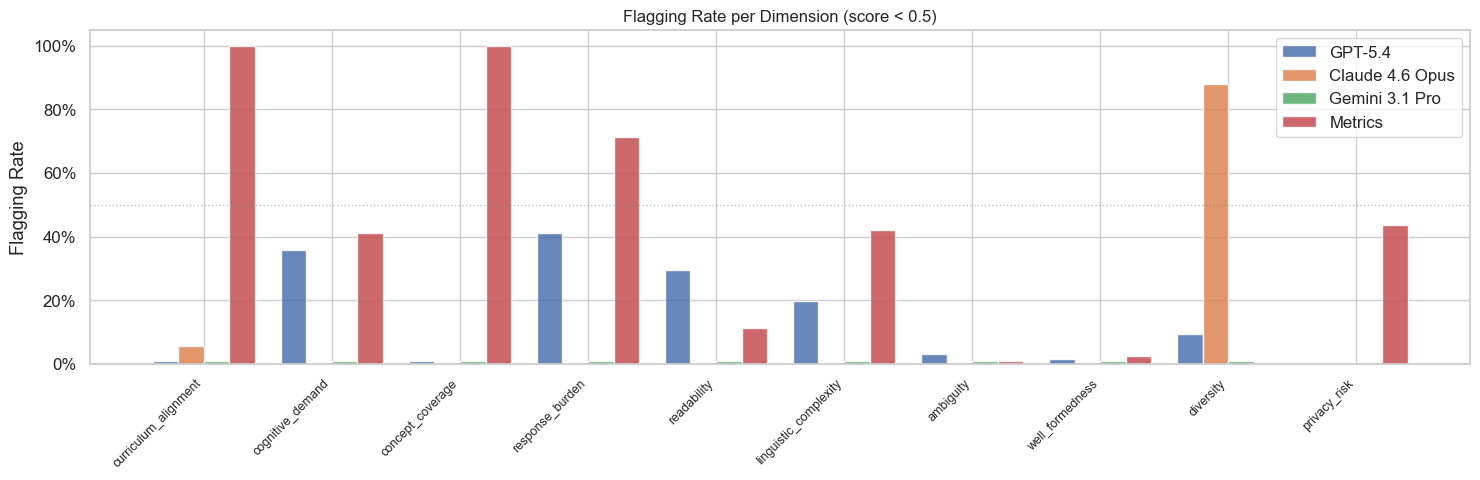

In [9]:
FLAG_THRESHOLD = 0.5
flag_rates = pd.DataFrame(
    {name: (df.loc[common_ids, shared_dims] < FLAG_THRESHOLD).mean() for name, df in all_dfs.items()},
    index=shared_dims
)

fig, ax = plt.subplots(figsize=(15, 5))
x, width = np.arange(len(shared_dims)), 0.2
for i, name in enumerate(all_dfs):
    ax.bar(x + i * width, flag_rates[name], width, label=name, color=COLORS[name], alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(shared_dims, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Flagging Rate')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title(f'Flagging Rate per Dimension (score < {FLAG_THRESHOLD})', fontsize=12)
ax.axhline(0.5, color='grey', linestyle=':', lw=1, alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(LLM_DIR / '6.042J_flagging_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 — Inter-LLM Agreement (Per-Question Variance)

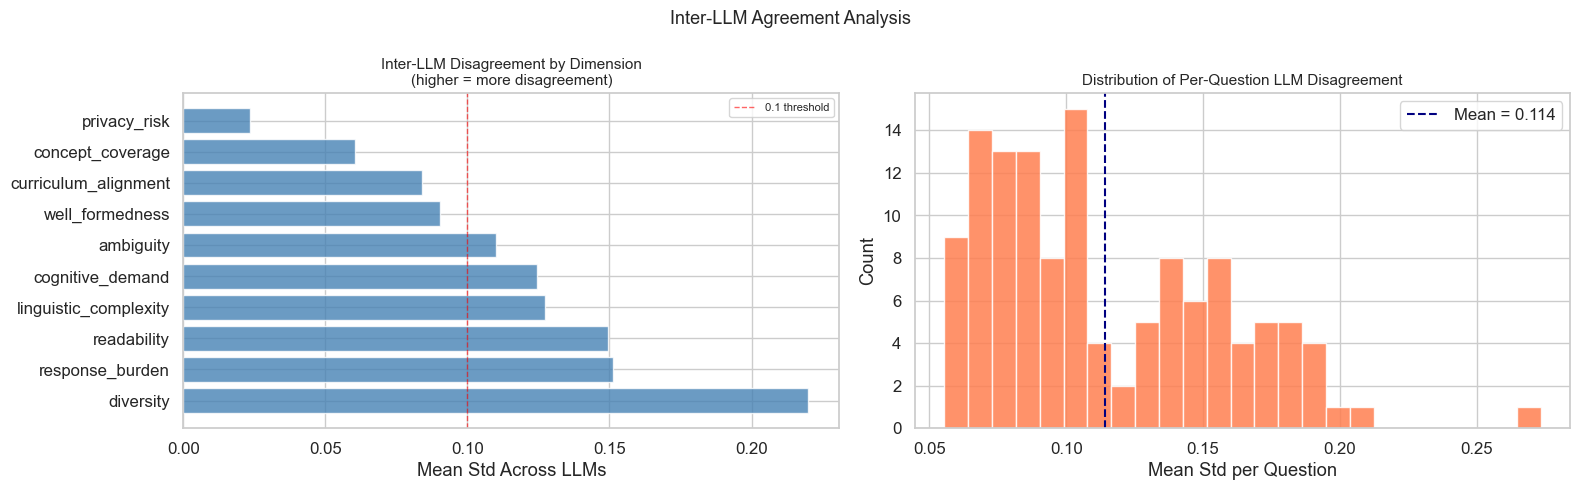


Top 5 most disagreed-upon questions:
question_id
6.042J-E0101    0.273369
6.042J-E0126    0.208392
6.042J-A0046    0.201634
6.042J-A0025    0.193028
6.042J-A0026    0.191242
dtype: float64


In [10]:
llm_stack = np.stack([llm_dfs[n].loc[common_ids, shared_dims].values for n in llm_dfs], axis=0)
llm_std   = np.nanstd(llm_stack, axis=0)  # (n_questions, n_dims)
std_df    = pd.DataFrame(llm_std, index=common_ids, columns=shared_dims)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mean_std = std_df.mean().sort_values(ascending=False)
axes[0].barh(mean_std.index, mean_std.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Mean Std Across LLMs')
axes[0].set_title('Inter-LLM Disagreement by Dimension\n(higher = more disagreement)', fontsize=11)
axes[0].axvline(0.1, color='red', linestyle='--', lw=1, alpha=0.6, label='0.1 threshold')
axes[0].legend(fontsize=8)

per_q_std = std_df.mean(axis=1)
axes[1].hist(per_q_std, bins=25, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(per_q_std.mean(), color='navy', linestyle='--', lw=1.5,
                label=f'Mean = {per_q_std.mean():.3f}')
axes[1].set_xlabel('Mean Std per Question')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Per-Question LLM Disagreement', fontsize=11)
axes[1].legend()

plt.suptitle('Inter-LLM Agreement Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(LLM_DIR / '6.042J_llm_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most disagreed-upon questions:')
print(per_q_std.sort_values(ascending=False).head())

## 9 — Summary Table

In [11]:
summary_stats = []
for name, df in all_dfs.items():
    flat = df.loc[common_ids, shared_dims].values.flatten()
    flat = flat[~np.isnan(flat)]
    summary_stats.append({
        'Source': name,
        'N Questions': len(common_ids),
        'N Dims Scored': int(df.loc[common_ids, shared_dims].notna().any().sum()),
        'Mean': flat.mean(),
        'Std': flat.std(),
        'Min': flat.min(),
        'Median': float(np.median(flat)),
        'Max': flat.max(),
        'Flag Rate (<0.5)': float((flat < 0.5).mean()),
    })

summary_table = pd.DataFrame(summary_stats).set_index('Source')
display(summary_table.style
    .format({'Mean': '{:.3f}', 'Std': '{:.3f}', 'Min': '{:.3f}',
             'Median': '{:.3f}', 'Max': '{:.3f}', 'Flag Rate (<0.5)': '{:.1%}'})
    .background_gradient(cmap='YlGn', subset=['Mean'])
    .background_gradient(cmap='YlOrRd', subset=['Flag Rate (<0.5)']))

,N Questions,N Dims Scored,Mean,Std,Min,Median,Max,Flag Rate (<0.5)
Source,,,,,,,,
GPT-5.4,126,10,0.717,0.208,0.000,0.770,1.000,14.2%
Claude 4.6 Opus,126,10,0.789,0.187,0.300,0.850,1.000,9.4%
Gemini 3.1 Pro,126,10,0.917,0.093,0.000,0.950,1.000,0.7%
Metrics,126,10,0.528,0.216,0.123,0.561,1.000,41.3%
